# MWE 07 - Synthetic vug grayscale workflow

This notebook uses the grayscale synthetic volume `examples/data/syn_vugs/synthetic_vugs.tif`
and now relies on reusable preprocessing and extraction helpers exposed by `voids`.

Shared code moved from the notebook into the library includes:
- cylindrical-sample support reconstruction by slice-wise hole filling
- largest common rectangular crop detection
- grayscale thresholding to binary void/solid phases
- PoreSpy `snow2` extraction, import, and longest-axis spanning pruning

The notebook remains responsible for the scientific interpretation, diagnostics, solve, and visualization.

Dataset attribution for `synthetic_vugs.tif`:
Chang, B., Turhan, C., Giakoumi, M., Prodanovic, M. (2026, January 28).
Companion Data for Digital Porous Media Tutorials [Dataset]. Digital Porous Media Portal.
https://doi.org/10.17612/2k9b-1h71




In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from skimage.io import imread

from voids.geom import characteristic_size
from voids.graph.connectivity import connected_components
from voids.graph.metrics import coordination_numbers
from voids.io.hdf5 import save_hdf5
from voids.paths import data_path
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization import plot_network_plotly
from voids.workflows import (
    extract_spanning_porespy_network,
    infer_sample_axes,
    preprocess_grayscale_cylindrical_volume,
)

examples_data = data_path()

In [2]:
raw_path = examples_data / "syn_vugs" / "synthetic_vugs.tif"
raw = imread(raw_path).astype(float)
voxel_size = 1.0e-6  # length unit is voxel because the TIFF has no spatial calibration metadata here, assumed 1 um per voxel

pre = preprocess_grayscale_cylindrical_volume(
    raw,
    background_value=0.0,
    threshold_method="otsu",
    void_phase="dark",
    show_progress=True,
    progress_desc="MWE07: filling cylindrical support slices",
)

crop_y0, crop_y1, crop_x0, crop_x1 = pre.crop.crop_bounds_yx
crop = pre.crop.cropped
threshold = pre.threshold
im = pre.binary
_, axis_lengths, axis_areas, flow_axis = infer_sample_axes(
    im.shape, voxel_size=voxel_size
)

print(
    "Raw grayscale shape:",
    raw.shape,
    raw.dtype,
    f"min={raw.min():.1f}",
    f"max={raw.max():.1f}",
)
print("Crop bounds (y0, y1, x0, x1):", (crop_y0, crop_y1, crop_x0, crop_x1))
print("Cropped shape:", crop.shape)
print(
    f"{pre.threshold_method.title()} threshold on cropped grayscale volume = {threshold:.2f}"
)
print(f"Void phase assumption = {pre.void_phase}")
print(f"Void fraction after binarization = {float(im.mean()):.4f}")
print("Axis lengths:", axis_lengths)
print("Longest axis for flow analysis:", flow_axis)

/Users/dtvolpatto/Work/voids/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
                                                                                 

Raw grayscale shape: (19, 234, 234) float64 min=0.0 max=227.0
Crop bounds (y0, y1, x0, x1): (65, 173, 57, 164)
Cropped shape: (19, 108, 107)
Otsu threshold on cropped grayscale volume = 93.60
Void phase assumption = dark
Void fraction after binarization = 0.1719
Axis lengths: {'x': 1.8999999999999998e-05, 'y': 0.000108, 'z': 0.000107}
Longest axis for flow analysis: y


## Raw, cropped, and binarized views

The first panel shows the middle raw slice with the largest common rectangle overlaid. The remaining panels show the cropped grayscale slice, the binary void/solid segmentation, and the grayscale histogram used to choose the threshold.





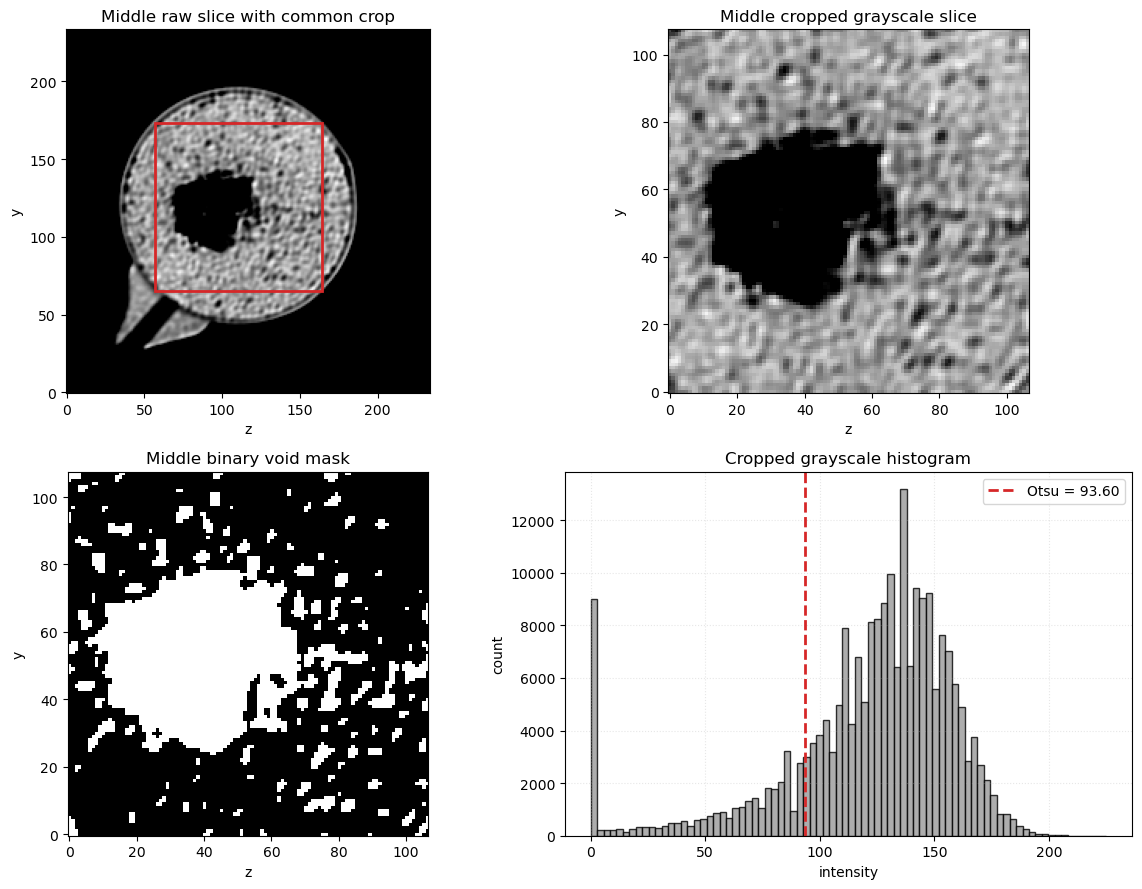

In [3]:
mid_raw = raw.shape[0] // 2
mid_crop = im.shape[0] // 2

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(raw[mid_raw], cmap="gray", origin="lower")
axes[0, 0].add_patch(
    Rectangle(
        (crop_x0, crop_y0),
        crop_x1 - crop_x0,
        crop_y1 - crop_y0,
        linewidth=2,
        edgecolor="tab:red",
        facecolor="none",
    )
)
axes[0, 0].set_title("Middle raw slice with common crop")
axes[0, 0].set_xlabel("z")
axes[0, 0].set_ylabel("y")

axes[0, 1].imshow(crop[mid_crop], cmap="gray", origin="lower")
axes[0, 1].set_title("Middle cropped grayscale slice")
axes[0, 1].set_xlabel("z")
axes[0, 1].set_ylabel("y")

axes[1, 0].imshow(im[mid_crop], cmap="gray", origin="lower")
axes[1, 0].set_title("Middle binary void mask")
axes[1, 0].set_xlabel("z")
axes[1, 0].set_ylabel("y")

axes[1, 1].hist(crop.ravel(), bins=80, color="0.6", edgecolor="black", alpha=0.8)
axes[1, 1].axvline(
    threshold,
    color="tab:red",
    linewidth=2,
    linestyle="--",
    label=f"Otsu = {threshold:.2f}",
)
axes[1, 1].set_title("Cropped grayscale histogram")
axes[1, 1].set_xlabel("intensity")
axes[1, 1].set_ylabel("count")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, linestyle=":")

plt.tight_layout()
plt.show()

In [4]:
extract = extract_spanning_porespy_network(
    im,
    voxel_size=voxel_size,
    flow_axis=flow_axis,
    length_unit="voxel",
    provenance_notes={
        "raw_source": raw_path.name,
        "crop_bounds_yx": [int(crop_y0), int(crop_y1), int(crop_x0), int(crop_x1)],
        "threshold_otsu": threshold,
        "void_phase": pre.void_phase,
    },
)

print("PoreSpy version:", extract.porespy_version)
print("Extracted keys sample:", list(extract.network_dict.keys())[:10])

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


[04:13:35] WARNING  Image was cropped to (18, 108, 106) during watershed                              ]8;id=113482;file:///Users/dtvolpatto/Work/voids/.pixi/envs/default/lib/python3.12/site-packages/porespy/networks/_snow2.py\_snow2.py]8;;\:]8;id=821628;file:///Users/dtvolpatto/Work/voids/.pixi/envs/default/lib/python3.12/site-packages/porespy/networks/_snow2.py#231\231]8;;\

PoreSpy version: 3.0.4
Extracted keys sample: ['throat.conns', 'pore.coords', 'pore.all', 'throat.all', 'pore.region_label', 'pore.phase', 'throat.phases', 'pore.region_volume', 'pore.equivalent_diameter', 'pore.local_peak']


In [5]:
net_dict = extract.network_dict
sample = extract.sample
prov = extract.provenance
axis_lengths = extract.axis_lengths
axis_areas = extract.axis_areas
flow_axis = extract.flow_axis
net_full = extract.net_full
net = extract.net
pore_idx_keep = extract.pore_indices
throat_mask_keep = extract.throat_mask

print(f"Imported full network: {net_full.Np} pores, {net_full.Nt} throats")
print(
    f"Pruned longest-axis ({flow_axis}) spanning network: {net.Np} pores, {net.Nt} throats"
)
print(
    f"Removed disconnected material: {net_full.Np - net.Np} pores, {net_full.Nt - net.Nt} throats"
)
net

Imported full network: 337 pores, 655 throats
Pruned longest-axis (y) spanning network: 314 pores, 653 throats
Removed disconnected material: 23 pores, 2 throats


Network(throat_conns=array([[  0,   5],
       [  0, 100],
       [  0, 288],
       ...,
       [276, 313],
       [277, 283],
       [285, 287]]), pore_coords=array([[4.25806452e-06, 3.64516129e-06, 4.96774194e-06],
       [4.12941176e-06, 9.66470588e-06, 5.51764706e-05],
       [7.53103448e-06, 6.33793103e-06, 7.17586207e-05],
       [4.42857143e-06, 3.28571429e-06, 7.58571429e-05],
       [3.95652174e-06, 4.56521739e-06, 1.05739130e-04],
       [5.11764706e-06, 7.47058824e-06, 1.93235294e-05],
       [8.17808219e-06, 4.43835616e-06, 1.06589041e-04],
       [4.91304348e-06, 9.13043478e-06, 4.10326087e-05],
       [4.07142857e-06, 1.08571429e-05, 9.01428571e-05],
       [3.73333333e-06, 1.11333333e-05, 9.97333333e-05],
       [4.59223301e-06, 1.70388350e-05, 8.13786408e-05],
       [4.78571429e-06, 1.54285714e-05, 1.00500000e-04],
       [5.85454545e-06, 1.88727273e-05, 1.54909091e-05],
       [5.65909091e-06, 1.91931818e-05, 4.17954545e-05],
       [4.97260274e-06, 1.98767123e-05, 8

In [6]:
print("phi_image(void fraction) =", float(im.mean()))
print("phi_abs(pruned region volumes / bulk) =", absolute_porosity(net))
print(
    f"phi_eff_{flow_axis}(pruned region volumes / bulk) =",
    effective_porosity(net, axis=flow_axis),
)

phi_image(void fraction) = 0.17194986427647518
phi_abs(pruned region volumes / bulk) = 0.1648630923102148
phi_eff_y(pruned region volumes / bulk) = 0.1648630923102148


In [7]:
# Single-phase solve on the pruned spanning network.
# Because the TIFF has no calibration metadata here, lengths are in voxel units and
# permeability is reported in voxel-scaled units rather than a physical SI unit.
bc = PressureBC(
    f"inlet_{flow_axis}min", f"outlet_{flow_axis}max", pin=2.0e5, pout=1.0e5
)
res = solve(
    net,
    fluid=FluidSinglePhase(viscosity=1.0e-3),
    bc=bc,
    axis=flow_axis,
    options=SinglePhaseOptions(
        conductance_model="valvatne_blunt_baseline", solver="direct"
    ),
)
print("Q =", res.total_flow_rate)
print(f"K{flow_axis} (length unit = voxel) =", res.permeability[flow_axis])
print("mbe =", res.mass_balance_error)

Q = 2.7070194804345114e-11
Ky (length unit = voxel) = 1.4380624883764254e-14
mbe = 1.3095527904185012e-24


In [8]:
out_dir = examples_data / "syn_vugs"
out_h5_full = out_dir / "synthetic_vugs_network_full_voids.h5"
out_h5 = out_dir / f"synthetic_vugs_network_{flow_axis}spanning_voids.h5"
out_npz = out_dir / "synthetic_vugs_network_raw.npz"
out_seg = out_dir / "synthetic_vugs_cropped_binary.npy"

save_hdf5(net_full, out_h5_full)
save_hdf5(net, out_h5)
np.savez_compressed(
    out_npz,
    **{k: np.asarray(v) for k, v in net_dict.items() if hasattr(v, "shape")},
    threshold_otsu=np.array([threshold], dtype=float),
    crop_bounds_yx=np.array([crop_y0, crop_y1, crop_x0, crop_x1], dtype=int),
)
np.save(out_seg, im)

print("Saved:", out_h5_full)
print("Saved:", out_h5)
print("Saved:", out_npz)
print("Saved:", out_seg)

Saved: /Users/dtvolpatto/Work/voids/examples/data/syn_vugs/synthetic_vugs_network_full_voids.h5
Saved: /Users/dtvolpatto/Work/voids/examples/data/syn_vugs/synthetic_vugs_network_yspanning_voids.h5
Saved: /Users/dtvolpatto/Work/voids/examples/data/syn_vugs/synthetic_vugs_network_raw.npz
Saved: /Users/dtvolpatto/Work/voids/examples/data/syn_vugs/synthetic_vugs_cropped_binary.npy


## Network Statistics

Inspect standard pore-network diagnostics on the pruned longest-axis spanning network obtained from the cropped and thresholded vug volume.





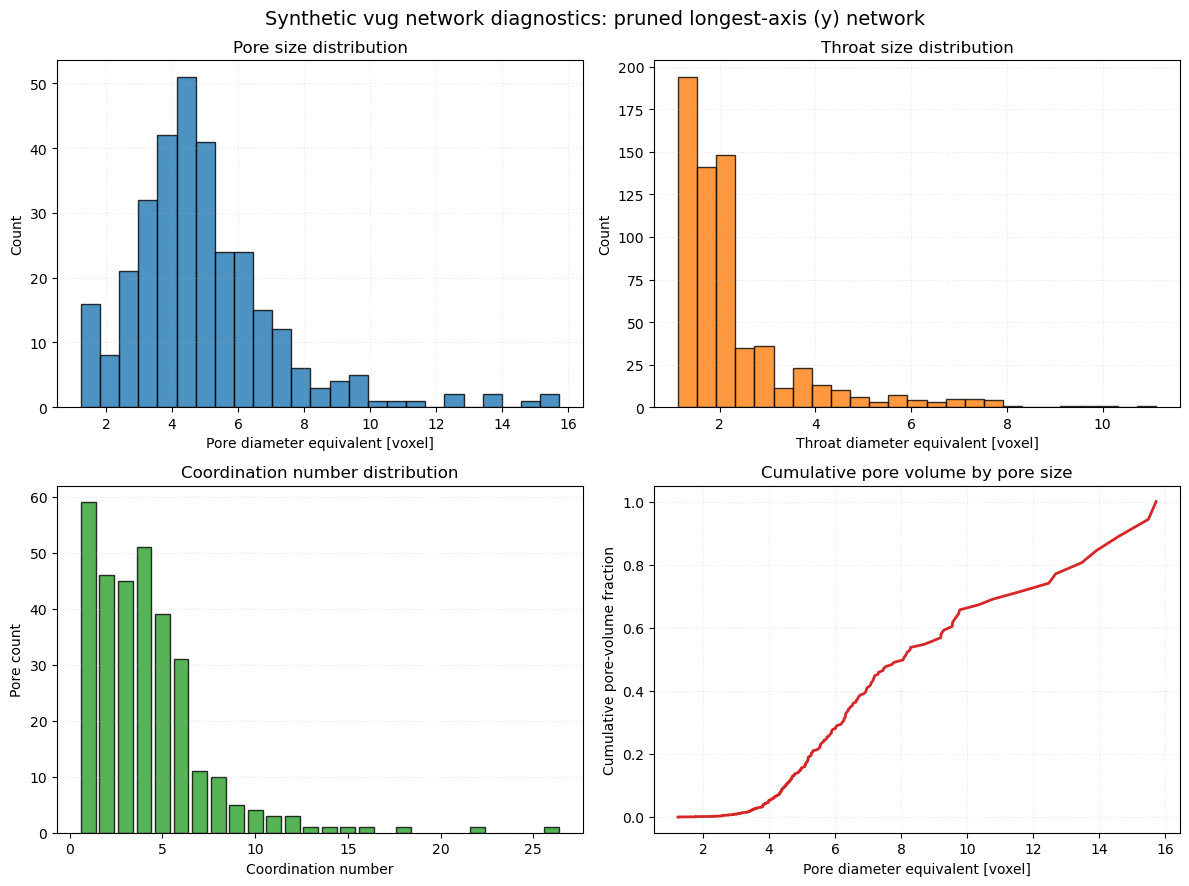

Pore size field: diameter_equivalent
Throat size field: diameter_equivalent
Mean pore size: 4.98 voxel
Median pore size: 4.57 voxel
Mean throat size: 2.21 voxel
Median throat size: 1.60 voxel
Mean coordination number: 4.16
Max coordination number: 26


In [9]:
pore_size_m, pore_size_field = characteristic_size(net.pore, expected_shape=(net.Np,))
throat_size_m, throat_size_field = characteristic_size(
    net.throat, expected_shape=(net.Nt,)
)
pore_size_name = pore_size_field.replace("_", " ")
throat_size_name = throat_size_field.replace("_", " ")
pore_size_vox = pore_size_m / voxel_size
throat_size_vox = throat_size_m / voxel_size

coordination = coordination_numbers(net)
coord_vals, coord_counts = np.unique(coordination, return_counts=True)

pore_volume = np.asarray(net.pore.get("region_volume", net.pore["volume"]), dtype=float)
order = np.argsort(pore_size_vox)
cum_pore_volume = np.cumsum(pore_volume[order]) / pore_volume.sum()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(pore_size_vox, bins=25, color="tab:blue", edgecolor="black", alpha=0.8)
axes[0, 0].set_xlabel(f"Pore {pore_size_name} [voxel]")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Pore size distribution")
axes[0, 0].grid(alpha=0.3, linestyle=":")

axes[0, 1].hist(
    throat_size_vox, bins=25, color="tab:orange", edgecolor="black", alpha=0.8
)
axes[0, 1].set_xlabel(f"Throat {throat_size_name} [voxel]")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Throat size distribution")
axes[0, 1].grid(alpha=0.3, linestyle=":")

axes[1, 0].bar(
    coord_vals, coord_counts, width=0.8, color="tab:green", edgecolor="black", alpha=0.8
)
axes[1, 0].set_xlabel("Coordination number")
axes[1, 0].set_ylabel("Pore count")
axes[1, 0].set_title("Coordination number distribution")
axes[1, 0].grid(alpha=0.3, linestyle=":", axis="y")

axes[1, 1].plot(pore_size_vox[order], cum_pore_volume, color="tab:red", linewidth=2)
axes[1, 1].set_xlabel(f"Pore {pore_size_name} [voxel]")
axes[1, 1].set_ylabel("Cumulative pore-volume fraction")
axes[1, 1].set_title("Cumulative pore volume by pore size")
axes[1, 1].grid(alpha=0.3, linestyle=":")

fig.suptitle(
    f"Synthetic vug network diagnostics: pruned longest-axis ({flow_axis}) network",
    fontsize=14,
)
plt.tight_layout()
plt.show()

print(f"Pore size field: {pore_size_field}")
print(f"Throat size field: {throat_size_field}")
print(f"Mean pore size: {pore_size_vox.mean():.2f} voxel")
print(f"Median pore size: {np.median(pore_size_vox):.2f} voxel")
print(f"Mean throat size: {throat_size_vox.mean():.2f} voxel")
print(f"Median throat size: {np.median(throat_size_vox):.2f} voxel")
print(f"Mean coordination number: {coordination.mean():.2f}")
print(f"Max coordination number: {coordination.max()}")

## Pruning Comparison

Compare the full extracted network (`net_full`) against the longest-axis spanning pruned network (`net`) to quantify what pruning removed and which transport-relevant statistics were preserved.





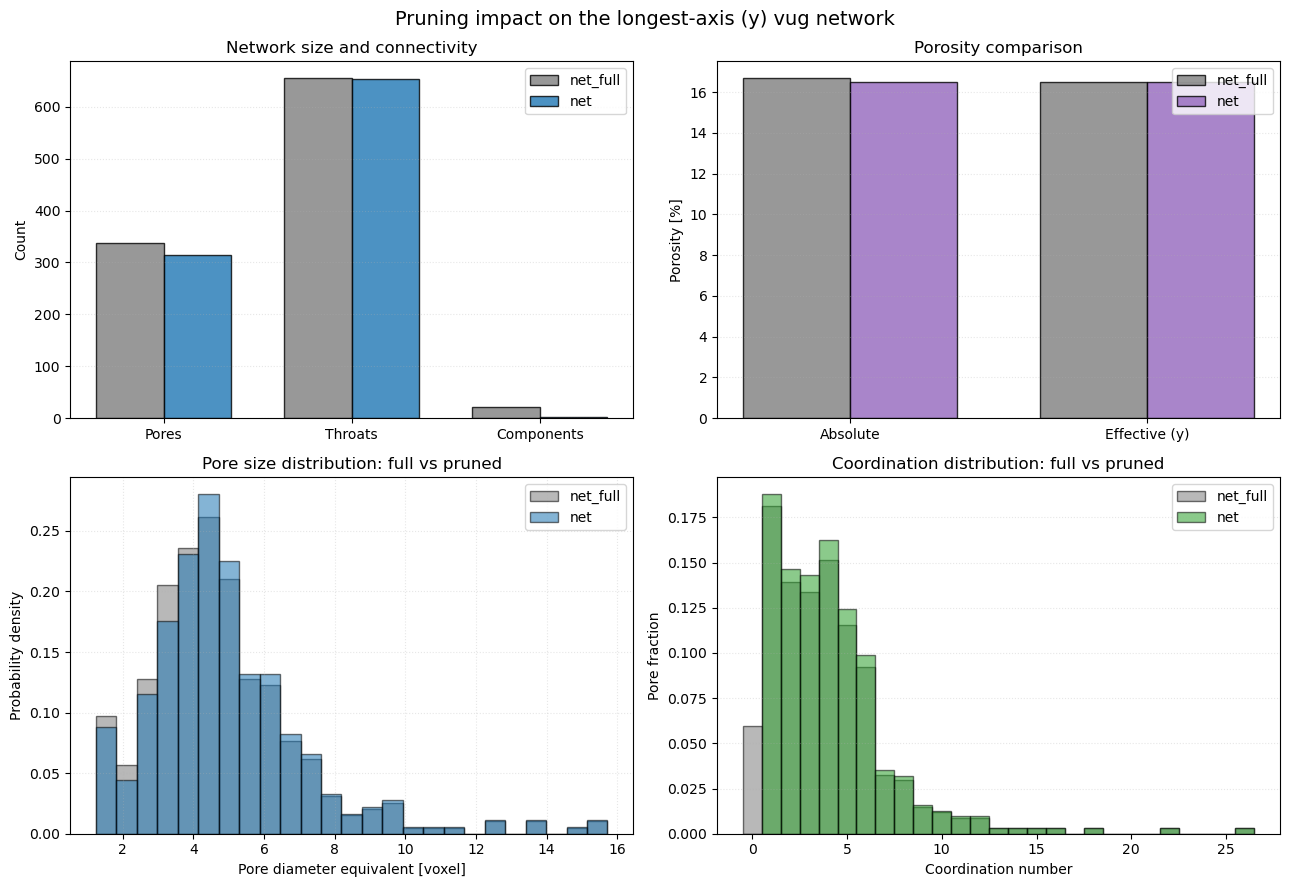

Full network: 337 pores, 655 throats, 22 connected components
Pruned network: 314 pores, 653 throats, 1 connected components
Removed by pruning: 23 pores, 2 throats, 21 components
Retained fractions: pores=93.18%, throats=99.69%, pore volume=98.85%
Absolute porosity: full=16.679%, pruned=16.486%
Effective porosity (y): full=16.486%, pruned=16.486%


In [10]:
full_pore_size_m, full_pore_size_field = characteristic_size(
    net_full.pore, expected_shape=(net_full.Np,)
)
pruned_pore_size_m, pruned_pore_size_field = characteristic_size(
    net.pore, expected_shape=(net.Np,)
)
full_pore_size_vox = full_pore_size_m / voxel_size
pruned_pore_size_vox = pruned_pore_size_m / voxel_size
full_coordination = coordination_numbers(net_full)
pruned_coordination = coordination_numbers(net)
full_pore_volume = np.asarray(
    net_full.pore.get("region_volume", net_full.pore["volume"]), dtype=float
)
pruned_pore_volume = np.asarray(
    net.pore.get("region_volume", net.pore["volume"]), dtype=float
)

phi_abs_full = absolute_porosity(net_full)
phi_abs_pruned = absolute_porosity(net)
phi_eff_full = effective_porosity(net_full, axis=flow_axis)
phi_eff_pruned = effective_porosity(net, axis=flow_axis)

n_comp_full, _ = connected_components(net_full)
n_comp_pruned, _ = connected_components(net)

removed_pores = net_full.Np - net.Np
removed_throats = net_full.Nt - net.Nt
removed_components = n_comp_full - n_comp_pruned
retained_pore_fraction = net.Np / net_full.Np if net_full.Np else np.nan
retained_throat_fraction = net.Nt / net_full.Nt if net_full.Nt else np.nan
retained_pore_volume_fraction = (
    pruned_pore_volume.sum() / full_pore_volume.sum()
    if full_pore_volume.sum()
    else np.nan
)
full_coordination_weights = (
    np.full(full_coordination.shape, 1.0 / full_coordination.size)
    if full_coordination.size
    else None
)
pruned_coordination_weights = (
    np.full(pruned_coordination.shape, 1.0 / pruned_coordination.size)
    if pruned_coordination.size
    else None
)

count_names = ["Pores", "Throats", "Components"]
full_counts = np.array([net_full.Np, net_full.Nt, n_comp_full], dtype=float)
pruned_counts = np.array([net.Np, net.Nt, n_comp_pruned], dtype=float)
porosity_names = ["Absolute", f"Effective ({flow_axis})"]
full_porosity_pct = 100.0 * np.array([phi_abs_full, phi_eff_full], dtype=float)
pruned_porosity_pct = 100.0 * np.array([phi_abs_pruned, phi_eff_pruned], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

x = np.arange(len(count_names))
width = 0.36
axes[0, 0].bar(
    x - width / 2,
    full_counts,
    width=width,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 0].bar(
    x + width / 2,
    pruned_counts,
    width=width,
    label="net",
    color="tab:blue",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 0].set_xticks(x, count_names)
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Network size and connectivity")
axes[0, 0].grid(alpha=0.3, linestyle=":", axis="y")
axes[0, 0].legend()

x = np.arange(len(porosity_names))
axes[0, 1].bar(
    x - width / 2,
    full_porosity_pct,
    width=width,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 1].bar(
    x + width / 2,
    pruned_porosity_pct,
    width=width,
    label="net",
    color="tab:purple",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 1].set_xticks(x, porosity_names)
axes[0, 1].set_ylabel("Porosity [%]")
axes[0, 1].set_title("Porosity comparison")
axes[0, 1].grid(alpha=0.3, linestyle=":", axis="y")
axes[0, 1].legend()

pore_bins = np.histogram_bin_edges(
    np.concatenate([full_pore_size_vox, pruned_pore_size_vox]), bins=25
)
axes[1, 0].hist(
    full_pore_size_vox,
    bins=pore_bins,
    density=True,
    alpha=0.55,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
)
axes[1, 0].hist(
    pruned_pore_size_vox,
    bins=pore_bins,
    density=True,
    alpha=0.55,
    label="net",
    color="tab:blue",
    edgecolor="black",
)
axes[1, 0].set_xlabel(f"Pore {pruned_pore_size_field.replace('_', ' ')} [voxel]")
axes[1, 0].set_ylabel("Probability density")
axes[1, 0].set_title("Pore size distribution: full vs pruned")
axes[1, 0].grid(alpha=0.3, linestyle=":")
axes[1, 0].legend()

max_coordination = max(
    int(np.max(full_coordination)) if full_coordination.size else 0,
    int(np.max(pruned_coordination)) if pruned_coordination.size else 0,
    1,
)
coord_bins = np.arange(-0.5, max_coordination + 1.5, 1.0)
axes[1, 1].hist(
    full_coordination,
    bins=coord_bins,
    weights=full_coordination_weights,
    alpha=0.55,
    label="net_full",
    color="tab:gray",
    edgecolor="black",
)
axes[1, 1].hist(
    pruned_coordination,
    bins=coord_bins,
    weights=pruned_coordination_weights,
    alpha=0.55,
    label="net",
    color="tab:green",
    edgecolor="black",
)
axes[1, 1].set_xlabel("Coordination number")
axes[1, 1].set_ylabel("Pore fraction")
axes[1, 1].set_title("Coordination distribution: full vs pruned")
axes[1, 1].grid(alpha=0.3, linestyle=":", axis="y")
axes[1, 1].legend()

fig.suptitle(
    f"Pruning impact on the longest-axis ({flow_axis}) vug network", fontsize=14
)
plt.tight_layout()
plt.show()

print(
    f"Full network: {net_full.Np} pores, {net_full.Nt} throats, {n_comp_full} connected components"
)
print(
    f"Pruned network: {net.Np} pores, {net.Nt} throats, {n_comp_pruned} connected components"
)
print(
    f"Removed by pruning: {removed_pores} pores, {removed_throats} throats, {removed_components} components"
)
print(
    f"Retained fractions: pores={100.0 * retained_pore_fraction:.2f}%, throats={100.0 * retained_throat_fraction:.2f}%, pore volume={100.0 * retained_pore_volume_fraction:.2f}%"
)
print(
    f"Absolute porosity: full={100.0 * phi_abs_full:.3f}%, pruned={100.0 * phi_abs_pruned:.3f}%"
)
print(
    f"Effective porosity ({flow_axis}): full={100.0 * phi_eff_full:.3f}%, pruned={100.0 * phi_eff_pruned:.3f}%"
)

## Interactive network visualization

Visualize the extracted pore network with pores colored by pressure using Plotly for full 3D interactivity. The marker and throat sizes now follow the available characteristic-size fields automatically.





In [11]:
try:
    fig = plot_network_plotly(
        net,
        point_scalars=res.pore_pressure,
        max_throats=2000,
        title=f"Synthetic vug network - pruned longest-axis ({flow_axis}) pressure field",
        layout_kwargs={"width": 900, "height": 700},
    )
    fig.show()
    print(f"Network: {net.Np} pores, {net.Nt} throats")
    p_plot = res.pore_pressure[np.isfinite(res.pore_pressure)]
    print(f"Pressure range: {p_plot.min():.2e} to {p_plot.max():.2e} Pa")
except ImportError as exc:
    print(exc)

Network: 314 pores, 653 throats
Pressure range: 1.00e+05 to 2.00e+05 Pa
